Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       151
           1       0.63      0.65      0.64        80

    accuracy                           0.74       231
   macro avg       0.72      0.72      0.72       231
weighted avg       0.75      0.74      0.75       231



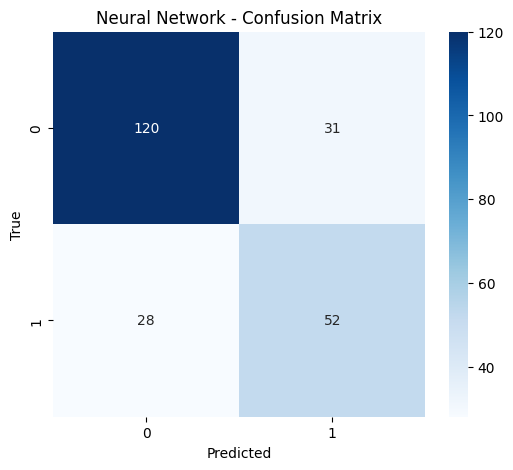

In [46]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)

# Load and preprocess data
columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness',
           'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
data = pd.read_csv('pima-indians-diabetes.data', delimiter=',', names=columns, header=None)

# Clean invalid zeros
invalid_zero_cols = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
data[invalid_zero_cols] = data[invalid_zero_cols].replace(0, np.nan)
data.fillna(data.median(numeric_only=True), inplace=True)

# Split and scale data
X = data.drop('outcome', axis=1)
y = data['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Neural Network Model - maxEpochs = 300
model = MLPClassifier(hidden_layer_sizes=(32, 16, 8), activation='relu',
                      solver='adam', max_iter=300, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Final predictions
y_pred = model.predict(X_test_scaled)

print("Neural Network Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Neural Network - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


=== Feature Selection Experiments ===

1. All Features Performance:
   Features: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age']
   Neural Network Accuracy: 0.7446

2. Top K Features (ANOVA F-test):
   K=4 features: ['glucose', 'insulin', 'bmi', 'age']
   Accuracy: 0.7576
   K=6 features: ['pregnancies', 'glucose', 'skin_thickness', 'insulin', 'bmi', 'age']
   Accuracy: 0.7013
   K=8 features: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age']
   Accuracy: 0.7446

3. Recursive Feature Elimination:
   4 features: ['glucose', 'bmi', 'diabetes_pedigree', 'age']
   Accuracy: 0.7532
   6 features: ['glucose', 'blood_pressure', 'insulin', 'bmi', 'diabetes_pedigree', 'age']
   Accuracy: 0.7532

4. Feature Importance Analysis:
   Feature Importance Ranking:
   glucose: 0.2829
   bmi: 0.1565
   age: 0.1397
   diabetes_pedigree: 0.1113
   blood_pressure: 0.0817
   insulin: 0.079

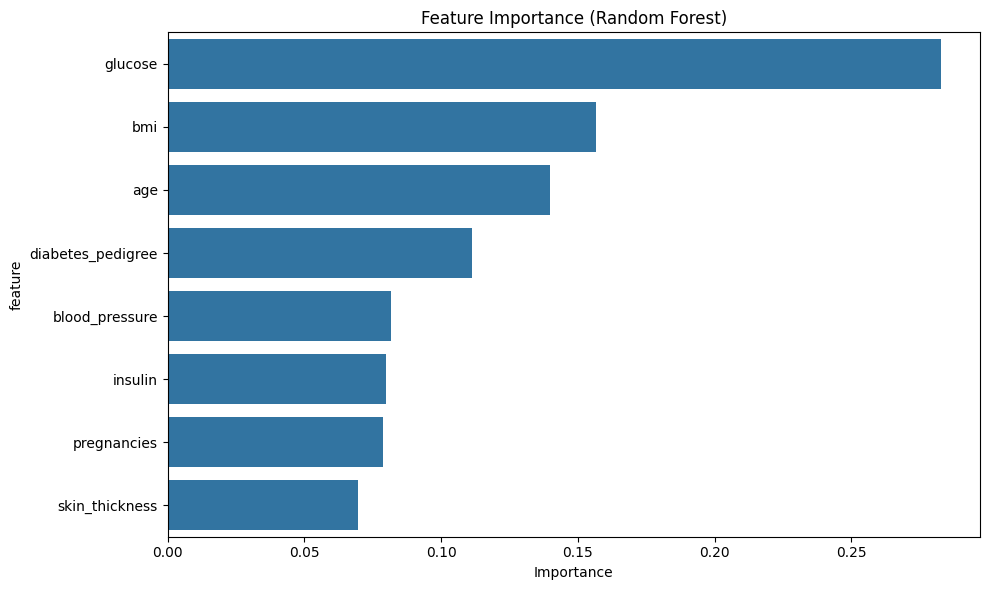

⚠️ Invalid input. Please enter numbers only.


In [47]:
# Feature Selection Experiments
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

print("=== Feature Selection Experiments ===\n")

# Helper function to create and train neural network
def train_neural_network(X_train, y_train, X_test, y_test):
    model = MLPClassifier(hidden_layer_sizes=(32, 16, 8), activation='relu',
                         solver='adam', max_iter=300, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

# 1. Original features (baseline)
print("1. All Features Performance:")
print(f"   Features: {list(X.columns)}")
print(f"   Neural Network Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 2. Select top K features using ANOVA F-test
print("\n2. Top K Features (ANOVA F-test):")
for k in [4, 6, 8]:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    
    # Get selected feature names
    selected_features = X.columns[selector.get_support()].tolist()
    
    # Train model with selected features
    accuracy = train_neural_network(X_train_selected, y_train, X_test_selected, y_test)
    
    print(f"   K={k} features: {selected_features}")
    print(f"   Accuracy: {accuracy:.4f}")

# 3. Recursive Feature Elimination (RFE)
print("\n3. Recursive Feature Elimination:")
for n_features in [4, 6]:
    rfe = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=n_features)
    X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
    X_test_rfe = rfe.transform(X_test_scaled)
    
    # Get selected feature names
    selected_features_rfe = X.columns[rfe.support_].tolist()
    
    # Train model with RFE selected features
    accuracy = train_neural_network(X_train_rfe, y_train, X_test_rfe, y_test)
    
    print(f"   {n_features} features: {selected_features_rfe}")
    print(f"   Accuracy: {accuracy:.4f}")

# 4. Feature importance analysis
print("\n4. Feature Importance Analysis:")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("   Feature Importance Ranking:")
for idx, row in feature_importance.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



Perceptron - Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.77      0.77       151
           1       0.56      0.55      0.56        80

    accuracy                           0.70       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.70      0.70      0.70       231



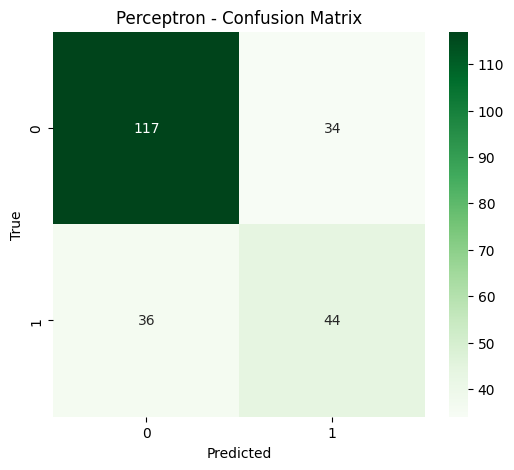


k-Nearest Neighbors (k=5) - Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.74      0.77       151
           1       0.57      0.64      0.60        80

    accuracy                           0.71       231
   macro avg       0.68      0.69      0.68       231
weighted avg       0.72      0.71      0.71       231



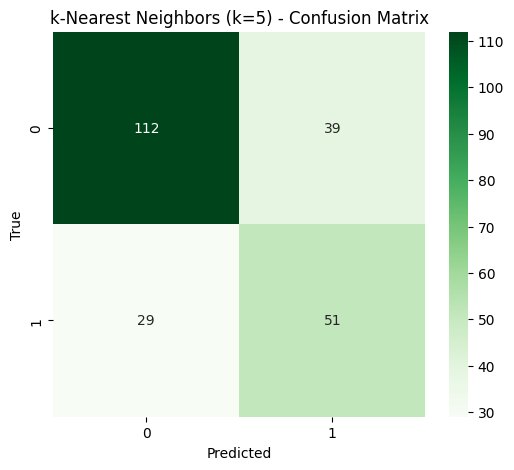


Decision Tree - Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       151
           1       0.56      0.60      0.58        80

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



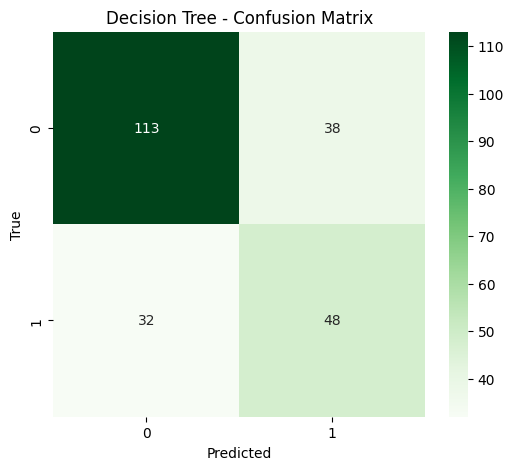

In [48]:
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Helper function to evaluate classifiers
def evaluate_classifier(model, name):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n{name} - Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Instantiate and evaluate classifiers
# Perceptron: maxEpochs = 1000 (defined as max_iter parameter)
perceptron = Perceptron(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
decision_tree = DecisionTreeClassifier(random_state=42)

# Evaluate all models
evaluate_classifier(perceptron, "Perceptron")
evaluate_classifier(knn, "k-Nearest Neighbors (k=5)")
evaluate_classifier(decision_tree, "Decision Tree")


In [49]:
from sklearn.model_selection import LeaveOneOut
from tqdm import tqdm

# LOOCV Function
def leave_one_out_cv(model, X, y, name):
    loo = LeaveOneOut()
    correct = 0

    print(f"\nRunning Leave-One-Out Cross-Validation for {name}...")
    for train_index, test_index in tqdm(loo.split(X), total=len(X)):
        X_train_loo, X_test_loo = X[train_index], X[test_index]
        y_train_loo, y_test_loo = y[train_index], y[test_index]

        model.fit(X_train_loo, y_train_loo)
        y_pred = model.predict(X_test_loo)

        correct += int(y_pred[0] == y_test_loo[0])

    accuracy = correct / len(y)
    print(f"\n{name} - LOOCV Accuracy: {accuracy:.4f}")

# Apply LOOCV on each model
leave_one_out_cv(perceptron, X_train_scaled, y_train.values, "Perceptron")
leave_one_out_cv(knn, X_train_scaled, y_train.values, "k-Nearest Neighbors (k=5)")
leave_one_out_cv(decision_tree, X_train_scaled, y_train.values, "Decision Tree")



Running Leave-One-Out Cross-Validation for Perceptron...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 537/537 [00:02<00:00, 233.97it/s]



Perceptron - LOOCV Accuracy: 0.7095

Running Leave-One-Out Cross-Validation for k-Nearest Neighbors (k=5)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 537/537 [00:03<00:00, 134.36it/s]



k-Nearest Neighbors (k=5) - LOOCV Accuracy: 0.7542

Running Leave-One-Out Cross-Validation for Decision Tree...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 537/537 [00:06<00:00, 86.25it/s]


Decision Tree - LOOCV Accuracy: 0.7132


In [50]:
# K-Means Clustering Analysis
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

print("=== K-Means Clustering ===")

# Use the already loaded data for clustering (remove class labels as required)
X_clustering = data.drop(['outcome'], axis=1)  # Remove class ID before clustering
y_clustering = data['outcome']

print(f"Dataset for clustering: {X_clustering.shape[0]} samples, {X_clustering.shape[1]} features")
print(f"Features: {list(X_clustering.columns)}")

=== K-Means Clustering ===
Dataset for clustering: 768 samples, 8 features
Features: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age']


In [51]:
# Scale the features for clustering
scaler_clustering = StandardScaler()
X_clustering_scaled = scaler_clustering.fit_transform(X_clustering)

print(f"Data scaled for clustering")
print(f"Feature means: {X_clustering_scaled.mean(axis=0).round(3)}")
print(f"Feature std: {X_clustering_scaled.std(axis=0).round(3)}")

Data scaled for clustering
Feature means: [-0.  0.  0. -0.  0.  0.  0.  0.]
Feature std: [1. 1. 1. 1. 1. 1. 1. 1.]


k=2: Inertia = 4975.02
k=3: Inertia = 4335.74
k=4: Inertia = 3912.70
k=5: Inertia = 3678.67
k=6: Inertia = 3474.50
k=7: Inertia = 3307.31


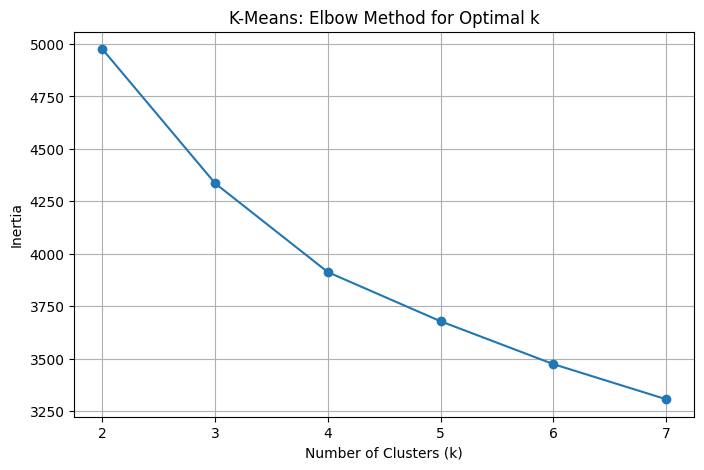

In [52]:
# Experiment with different k values
inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_clustering_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('K-Means: Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [53]:
# Final clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clustering_scaled)

print(f"Final K-Means Clustering (k=3)")
print(f"Cluster distribution:")
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples")

# Show cluster centers
print(f"\nCluster Centers:")
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"  Cluster {i}: {center}")
    
print(f"\nInertia: {kmeans.inertia_:.2f}")


Final K-Means Clustering (k=3)
Cluster distribution:
  Cluster 0: 248 samples
  Cluster 1: 335 samples
  Cluster 2: 185 samples

Cluster Centers:
  Cluster 0: [ 1.0470787   0.30028055  0.49869482  0.10381752 -0.01203346  0.05147404
 -0.04537878  1.08907535]
  Cluster 1: [-0.46459069 -0.49428384 -0.4651046  -0.5579768  -0.31670965 -0.57583692
 -0.18276281 -0.62093654]
  Cluster 2: [-0.56236561  0.49251627  0.17369582  0.87121882  0.58963261  0.97372869
  0.39178096 -0.33555105]

Inertia: 4335.74


In [54]:
# Compare clustering results to true class labels
print("=== Clustering vs True Labels Comparison ===")

# Show how clusters relate to true labels
cluster_analysis = pd.DataFrame({
    'true_label': y_clustering,
    'cluster': clusters
})

print("\nCluster composition by true labels:")
for cluster in sorted(np.unique(clusters)):
    cluster_data = cluster_analysis[cluster_analysis['cluster'] == cluster]
    diabetic_count = (cluster_data['true_label'] == 1).sum()
    non_diabetic_count = (cluster_data['true_label'] == 0).sum()
    total = len(cluster_data)
    
    print(f"Cluster {cluster} (n={total}):")
    print(f"  Non-diabetic: {non_diabetic_count} ({non_diabetic_count/total*100:.1f}%)")
    print(f"  Diabetic: {diabetic_count} ({diabetic_count/total*100:.1f}%)")

# Adjusted Rand Index
ari = adjusted_rand_score(y_clustering, clusters)
print(f"\nAdjusted Rand Index (k=3): {ari:.4f}")

# Confusion matrix-style analysis
print(f"\nDetailed cluster distribution:")
cluster_crosstab = pd.crosstab(clusters, y_clustering, margins=True)
print(cluster_crosstab)


=== Clustering vs True Labels Comparison ===

Cluster composition by true labels:
Cluster 0 (n=248):
  Non-diabetic: 120 (48.4%)
  Diabetic: 128 (51.6%)
Cluster 1 (n=335):
  Non-diabetic: 291 (86.9%)
  Diabetic: 44 (13.1%)
Cluster 2 (n=185):
  Non-diabetic: 89 (48.1%)
  Diabetic: 96 (51.9%)

Adjusted Rand Index (k=3): 0.1379

Detailed cluster distribution:
outcome    0    1  All
row_0                 
0        120  128  248
1        291   44  335
2         89   96  185
All      500  268  768


In [55]:
# Summary: Compare All Classifiers Performance
print("=== Classifier Performance Summary ===\n")

# Get all models
models = {
    "Neural Network": model,
    "Perceptron": perceptron,
    "k-Nearest Neighbors (k=5)": knn,
    "Decision Tree": decision_tree
}

# Compare performance
results = []
for name, clf in models.items():
    # Make sure model is trained
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate precision, recall, f1 for class 1 (diabetic)
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Display results table
results_df = pd.DataFrame(results)
print(results_df.round(4))

# Find best performing model
best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]

print(f"\nBest Accuracy: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
print(f"Best F1-Score: {best_f1['Model']} ({best_f1['F1-Score']:.4f})")

print(f"\nNeural Network Topology:")
print(f"- Hidden layers: {model.hidden_layer_sizes}")
print(f"- Activation: {model.activation}")
print(f"- Solver: {model.solver}")
print(f"- Max iterations: {model.max_iter}")


=== Classifier Performance Summary ===

                       Model  Accuracy  Precision  Recall  F1-Score
0             Neural Network    0.7446     0.6265  0.6500    0.6380
1                 Perceptron    0.6970     0.5641  0.5500    0.5570
2  k-Nearest Neighbors (k=5)    0.7056     0.5667  0.6375    0.6000
3              Decision Tree    0.6970     0.5581  0.6000    0.5783

Best Accuracy: Neural Network (0.7446)
Best F1-Score: Neural Network (0.6380)

Neural Network Topology:
- Hidden layers: (32, 16, 8)
- Activation: relu
- Solver: adam
- Max iterations: 300
